In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("superstore-dataset-EDA.txt")
df.head()

,Order Date,Order ID,Product Name,Category,City,Country,Customer Name,Discount,Postal Code,Manufacturer,Profit,Profit Ratio,Quantity,Region,Sales,Segment,Ship Date,Ship Mode,State,Sub-Category
0,11/8/2017,CA-2017-152156,Bush Somerset Collection Bookcase,Furniture,Henderson,United States,Claire Gute,0.00%,42420.0,Bush,$42.00,16.00%,2.0,South,$262.00,Consumer,11/11/2017,Second Class,Kentucky,Bookcases
1,11/8/2017,CA-2017-152156,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,Henderson,United States,Claire Gute,0.00%,42420.0,Hon,$220.00,30.00%,3.0,South,$732.00,Consumer,11/11/2017,Second Class,Kentucky,Chairs
2,6/12/2017,CA-2017-138688,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,Los Angeles,United States,Darrin Van Huff,0.00%,90036.0,Universal,$7.00,47.00%,2.0,West,$15.00,Corporate,6/16/2017,Second Class,California,Labels
3,10/11/2016,US-2016-108966,Bretford CR4500 Series Slim Rectangular Table,Furniture,Fort Lauderdale,United States,Sean O'Donnell,45.00%,33311.0,Bretford,-$383.00,-40.00%,5.0,South,$958.00,Consumer,10/18/2016,Standard Class,Florida,Tables
4,10/11/2016,US-2016-108966,Eldon Fold 'N Roll Cart System,Office Supplies,Fort Lauderdale,United States,Sean O'Donnell,20.00%,33311.0,Eldon,$3.00,11.00%,2.0,South,$22.00,Consumer,10/18/2016,Standard Class,Florida,Storage


df['Sales'] = df['Sales'].replace('[\$,]', '', regex=True).astype(float)
df['Profit'] = df['Profit'].replace('[\$,]', '', regex=True).astype(float)
df['Quantity'] = df['Quantity'].astype(float)

Graph 1: Sales Distribution

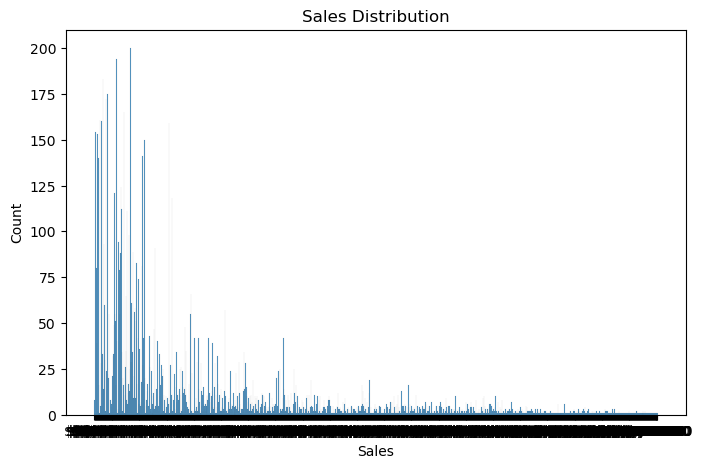

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")

plt.show()

Graph 2: Boxplot

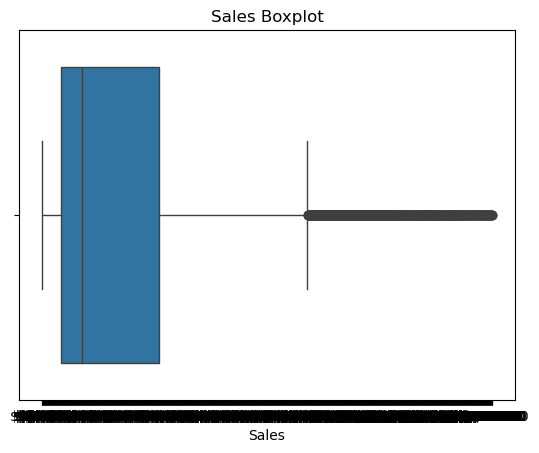

In [12]:
sns.boxplot(x=df['Sales'])
plt.title("Sales Boxplot")
plt.show()

### Observation:
The boxplot shows several outliers in sales data, indicating some products have very high sales values.

Graph 3: Quantity vs Sales

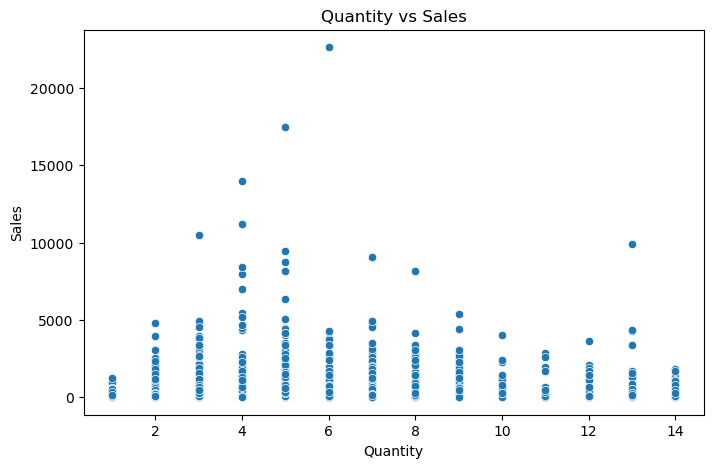

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Quantity', y='Sales', data=df)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

In [21]:
df['Sales'] = df['Sales'].replace('[$,]', '', regex=True).astype(float)

df['Profit'] = df['Profit'].replace('[$,]', '', regex=True).astype(float)

Graph 4: Correlation

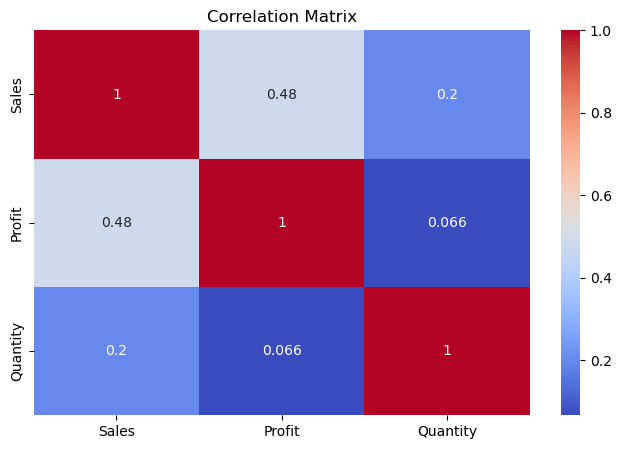

In [23]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Sales','Profit','Quantity']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Graph 5: Region-wise Sales

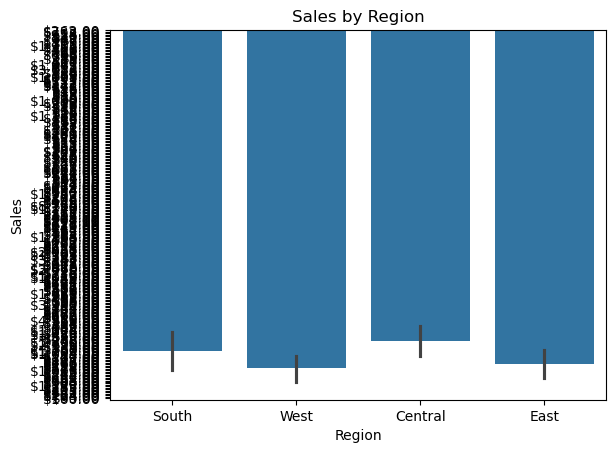

In [15]:
sns.barplot(x='Region', y='Sales', data=df)
plt.title("Sales by Region")
plt.show()

GRAPH 6: Category-wise Sales

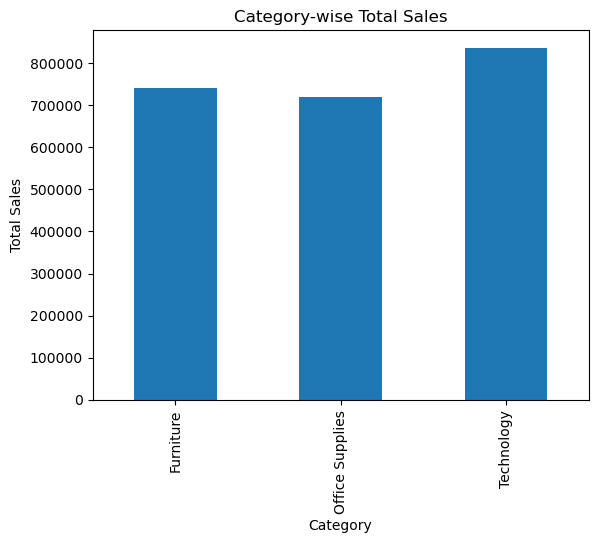

In [24]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')

plt.title("Category-wise Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

# Conclusion

1. Technology category has the highest sales.
2. Furniture category contributes significant sales.
3. Office Supplies category has comparatively lower sales.
4. Sales and Profit have moderate positive correlation.
5. Quantity has weak correlation with Profit.
6. Some outliers are present in Sales data.
7. Regional sales vary across different regions.